---
```
Name: Lê Nam Phong
Student ID: SE204029
Class: AI2010
Lab: 02
```
---

Submission Link: https://forms.gle/XXundeEcPkfzQ8Yz5 

In [1]:
# --- environment bootstrap (works in both the notebook and the script) ---
import os, sys

_here = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
for _p in (_here, os.path.abspath(os.path.join(_here, os.pardir))):
    if _p not in sys.path:
        sys.path.insert(0, _p)

# In script (headless) context, render figures off-screen so saving works.
if "__file__" in globals():
    import matplotlib
    matplotlib.use("Agg")

# Edge Detection &amp; Features

This combined lab (** Edge Detection** + **08 Features**) is built around **four real-world product scenarios**. For each you implement one function and a **self-check** confirms it works (✓ PASS / ✗ TODO).

| # | You're building… | Technique | Scoring (10 pts) |
|---|---|---|---|
| **Q1** | a car's lane-keeping assist | Canny + Hough (edges) | Coding 1.5 pts, Discussion questions: 1 pts |
| **Q2** | a camera's autofocus | Laplacian variance (edges) | Coding 1.5 pts, Discussion questions: 1 pts |
| **Q3** | a phone's panorama mode | ORB + RANSAC + warp (features) | Coding 1.5 pts, Discussion questions: 1 pts |
| **Q4** | a visual product search | feature match + homography (features) | Coding 1.5 pts, Discussion questions: 1 pts |

Everything is **self-contained** — data is built from bundled sample images plus synthetic shapes, so it runs fully offline. The notebook runs top-to-bottom even before you start (checks show ✗ TODO until you fill the `# TODO`).

## Setup — run me first

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from utils.data import load_sample
from utils.viz import show_image, show_grid, side_by_side, finish

def check(name, cond):
    print(('\u2713 PASS  ' if cond else '\u2717 TODO  ') + name)

# --- Q1 data: a synthetic dashcam 'road' with two lane lines + noise ---
road = np.zeros((300, 400), np.uint8)
cv2.line(road, (60, 290), (180, 40), 255, 3); cv2.line(road, (360, 290), (230, 40), 255, 3)
road = cv2.add(road, (np.random.default_rng(0).random(road.shape) * 40).astype(np.uint8))

# --- Q2 data: a grayscale frame for the autofocus stack ---
gray = load_sample('camera')

# --- Q3 data: two overlapping 'photos' (warp a sample to fake a panning camera) ---
astro = load_sample('astronaut'); h, w = astro.shape[:2]
H_true = np.array([[1.0, 0.10, 60.0], [0.04, 1.0, 5.0], [0.0002, 0.0, 1.0]])
canvas_w = w + 220
view2 = cv2.warpPerspective(astro, H_true, (canvas_w, h))
view1 = np.zeros((h, canvas_w, 3), np.uint8); view1[:, :w] = astro

# --- Q4 data: a 'shelf' scene with a known product pasted in at OBJ_XY ---
scene = cv2.resize(load_sample('coffee'), (500, 400))
obj = cv2.resize(astro[40:170, 300:430], (120, 120))
OBJ_XY = (310, 240)
scene[OBJ_XY[1]:OBJ_XY[1]+120, OBJ_XY[0]:OBJ_XY[0]+120] = obj
query = obj.copy()
print('lab data ready (all offline)')

lab data ready (all offline)


[saved] outputs/lab_data.png


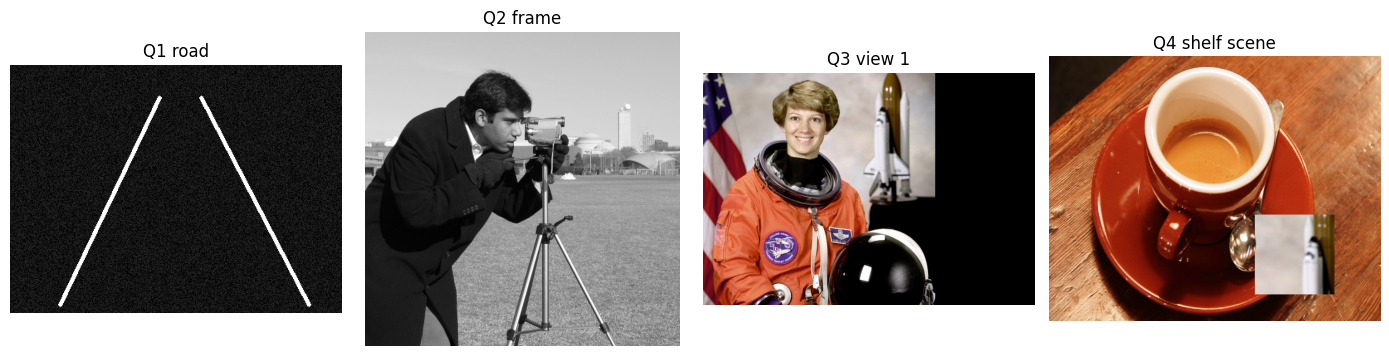

In [3]:
# Preview the four scenarios' data
show_grid([road, gray, view1, scene],
          titles=['Q1 road', 'Q2 frame', 'Q3 view 1', 'Q4 shelf scene'], cols=4, cmap='gray')
finish(save_as='lab_data.png')

## Question 1 — Driver assistance: detect the lane lines

### Real-world context
**The job.** You're on the perception team for a car's **lane-keeping assist (LKA)**. The forward camera streams ~30 fps and your module must find the painted **lane lines** every frame so the controller can center the car and warn on lane departure.

**In production.** Lightweight edge + Hough pipelines like this run on automotive vision chips (e.g. **Mobileye EyeQ**, in a huge share of new cars) and in open stacks like **comma.ai openpilot**; lane-departure warning is now mandated on new cars in the EU. Modern systems add a CNN lane segmenter, but a geometric **line-fit** stage almost always remains.

**Stakes.** Safety-critical: a *missed* line lets the car drift; a *false* line (a tar crack, a worn old marking, a shadow edge) can trigger phantom steering or braking. And it must hold ~30–60 fps on cheap, power-limited hardware.

**Where it sits in the pipeline.** edges (Canny) → line voting (Hough) → keep & smooth lines across frames → lane curvature / vanishing point → steering controller. Edges are the front end of the whole stack.

**How it breaks.** Faded or occluded paint, rain / glare / night, construction zones with conflicting markings, shadows that mimic edges, and **sharp curves** — straight-line Hough fails there, so real systems warp to a bird's-eye view and fit polynomials. You'll feel the threshold fragility in the Bloom question.

### Concept
Lane markings are high-contrast **edges**. Run **Canny** (smooth → gradient → non-max suppression → hysteresis) to get clean thin edges, then the **probabilistic Hough transform** (`cv2.HoughLinesP`) to turn those edge *pixels* into straight **line segments** — robust to the dashes and small occlusions of real lane paint because each pixel *votes* for the line through it.

### Your task
Implement `detect_lanes(frame_gray)` → a list of `(x1,y1,x2,y2)` segments: **Canny** then **`HoughLinesP`**. Tune the parameters so it finds the two lanes in the synthetic `road`. The check wants **≥ 2** segments.

In [ ]:
def detect_lanes(frame_gray):
    # TODO: Canny -> HoughLinesP ; return a list of (x1,y1,x2,y2) tuples
    return []
    

In [13]:
try:
    segs = detect_lanes(road); ok = len(segs) >= 2
    vis = cv2.cvtColor(road, cv2.COLOR_GRAY2BGR)
    for x1, y1, x2, y2 in segs: cv2.line(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    show_grid([road, cv2.Canny(road, 80, 160), cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)],
              titles=['dashcam frame', 'Canny edges', f'{len(segs)} lane segments'], cols=3, cmap='gray')
    finish(save_as='lab_q1_lanes.png')
except Exception as e:
    ok = False; print('   error:', e)
check('Q1: detect_lanes (>=2 segments)', ok)

   error: 'NoneType' object is not iterable
✗ TODO  Q1: detect_lanes (>=2 segments)


**Discussion questions.**
1. Hough is robust to **dashed** lines and a car partly covering a lane — discuss *why*, and where that robustness still isn't enough (construction zones, ghost markings from a repaved road).
2. On a **sharp curve**, straight-line Hough breaks down. Discuss two ways a production system could handle curves, and the trade-offs of each.
3. A **shadow** edge can masquerade as a lane line. What cues — colour, time (across frames), geometry — would you use to reject it?

**Answer questions.**
1. 
2. 
- Cách 1: dùng sliding windows kết hợp Polynomial Fit 
- Cách 2: dùng xấp xỉ tuyến tính, chia thành các vùng đủ nhỏ rồi dùng HoughLines để nối các line lại, các lines nếu đủ nhỏ sẽ làm cho cảm giác đó là đường cong
3. Vạch kẻ đường thường có màu trắng hoặc vàng, trong khi bóng chỉ làm giảm cường độ sáng. Về mặt thời gian thì bóng thay đổi liên tục theo hướng nắng -> lọc theo thời gian giữa các frame liên tiếp. Về mặt hình học, các vạch kẻ đường song song với lề đường còn vạch dừng thì vuông góc thường là hình chữ nhật có chiều rộng khoảng 10cm, tuy nhiên các bóng râm như cây cối, phương tiện thì không, còn về bóng của tòa nhà thì nó quá to so với kích thước của vạch kẻ đường chuẩn


## Question 2 — Smartphone camera: autofocus & blur rejection

### Real-world context
**The job.** You're building a **camera app** with two jobs: (1) **autofocus** — as the lens sweeps, pick the sharpest position; (2) **blur rejection** — don't save an obviously out-of-focus shot.

**In production.** Every phone does contrast-detection autofocus on a sharpness score like this; **whole-slide scanners** in pathology (Leica, Zeiss) autofocus thousands of tiles; **Apple/Google Photos** pick the 'best shot' from a burst and hide blurry ones; document-scanner apps refuse to capture until the page is sharp.

**Stakes.** A moving subject gives you **one chance** — a blurry frame is a lost moment; in pathology an out-of-focus tile can hide a diagnosis; slow autofocus just feels broken.

**Where it sits in the pipeline.** Laplacian (2nd derivative) → variance = sharpness → *maximize* over lens positions (AF) or *threshold* (blur reject) → keep the best frame → hand a **sharp** image to downstream OCR / recognition (which fail on blur).

**How it breaks.** **Noise inflates the score** (a noisy blurry frame can look 'sharp'); a low-texture scene (a blank wall) scores low regardless of focus; motion blur ≠ defocus; over-exposure flattens edges. Real systems **denoise first**, use a band-pass (Tenengrad) measure, and score a region-of-interest — exactly this question's Bloom prompt.

### Concept
A *sharp* image is full of strong edges; *blur* attenuates the high frequencies and weakens them. The **variance of the Laplacian** (the second derivative, Lecture 05 §2.4) is the classic single-number **sharpness score**: high when crisp edges abound, low once blur flattens them. Contrast-detection autofocus simply moves the lens to **maximize** it.

### Your task
Implement `focus_score(gray)` = the **variance** of `cv2.Laplacian(gray, cv2.CV_64F)`. The check builds a focus stack (sharp + increasingly blurred copies) and confirms your score **decreases monotonically** with blur and that its **argmax picks the in-focus frame**.

In [ ]:
def focus_score(gray):
    # TODO: return the variance of the Laplacian (one sharpness number)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    return laplacian.var()

   focus scores (sharp -> blurry): [np.float64(1133.2), np.float64(49.9), np.float64(7.4), np.float64(1.7), np.float64(1.1)]
[saved] outputs/lab_q2_focus.png


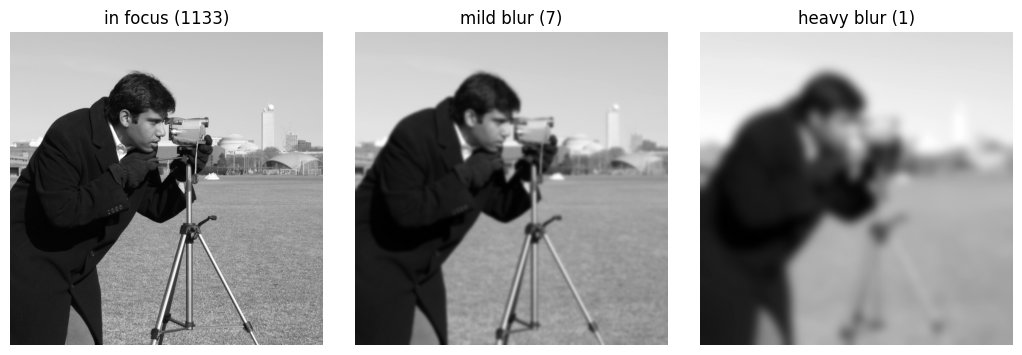

✓ PASS  Q2: focus_score (autofocus / blur rejection)


In [11]:
try:
    stack = [gray] + [cv2.GaussianBlur(gray, (0, 0), s) for s in (1, 2, 4, 8)]
    scores = [focus_score(im) for im in stack]
    print('   focus scores (sharp -> blurry):', [round(s, 1) for s in scores])
    mono = all(scores[i] > scores[i+1] for i in range(len(scores)-1))
    ok = mono and int(np.argmax(scores)) == 0
    show_grid([stack[0], stack[2], stack[4]],
              titles=[f'in focus ({scores[0]:.0f})', f'mild blur ({scores[2]:.0f})',
                      f'heavy blur ({scores[4]:.0f})'], cols=3, cmap='gray')
    finish(save_as='lab_q2_focus.png')
except Exception as e:
    ok = False; print('   error:', e)
check('Q2: focus_score (autofocus / blur rejection)', ok)

**Discussion questions.**
1. The score rises with both **sharpness and noise**. Discuss how you could tell a genuinely sharp frame from a noisy-but-blurry one.
2. Pointed at a **blank wall**, the score is low *no matter the focus*. Should the camera keep hunting, report 'can't focus,' or fall back to a fixed distance? Discuss the UX trade-offs.
3. **Motion blur** and **defocus** both lower the score but need different fixes. How might you distinguish them, and why does it matter?

**Answer questions.**
1. Genuinely sharp có tính liên tục và cấu trúc không gian rõ ràng như đường viền của vật thể còn nhiễu noise thì phân bố ngẫu nhiên, rời rạc. Dùng bộ dò cạnh như Canny, Sobel, nếu các cạnh được phát hiện là quá ngắn hoặc đứt đoạn thì có thể xem đó là nhiễu
2. 
- Keep hunting: có thể tìm thấy nét nếu người dùng di chuyển 1 chút nhưng gây lãng phí tài nguyên
- Report cant focus: trung thực nhưng làm gián đoạn cảm xúc người dùng khi phải sửa thủ công    
- Fall back to a fixed distance: tạo ra bức ảnh đủ ổn nhưng có thể bị out nét
3. 
- Defocus 

## Question 3 — Phone Panorama: stitch two photos into one

### Real-world context
**The job.** Build **Panorama** mode: the user pans the phone, you capture two **overlapping** photos, and merge them into one wide image.

**In production.** iPhone/Android Panorama and Google **Street View / Photo Sphere**; desktop stitchers (**PTGui, Hugin, AutoStitch**); drone-mapping platforms (**DroneDeploy, Pix4D**) that build field **orthomosaics**; **Matterport** real-estate tours; microscopy slide tiling; satellite mosaicking. The same alignment math also powers **HDR/burst merging, super-resolution, and video stabilization**.

**Stakes.** It turns a cheap narrow-FOV camera into a wide-angle one; in agriculture the stitched orthomosaic drives crop-health decisions over hundreds of acres — ghosting or misalignment corrupts the map farmers act on.

**Where it sits in the pipeline.** corners/features (ORB) → match (ratio test) → **RANSAC homography** → warp → **multiband blend**; for many images, add **bundle adjustment** to spread error globally.

**How it breaks.** **Parallax** (a non-planar scene shot while *translating* the camera) → ghosting; **moving objects** (people, cars) → ghosts; **repetitive texture** → wrong matches; too little overlap/texture → too few matches; **exposure differences** → a visible seam (why blending matters). RANSAC, seam-finding, and multiband blending are the production fixes.

### Concept
Find distinctive **corner features** in both images (ORB), **match** their descriptors with the ratio test, then **robustly** fit the **homography** that relates the two views with **RANSAC** (ignoring wrong matches). Finally **warp** the second image into the first's frame (`cv2.warpPerspective`) and composite. A homography is exact here because a panning camera rotates about its optical centre.

### Your task
Implement the full pipeline `stitch(view1, view2)` → a uint8 panorama: ORB detect+describe → `BFMatcher`(Hamming)+ratio test → `findHomography(..., cv2.RANSAC)` (view2→view1) → `warpPerspective` onto view1's canvas → composite (fill empties; average the overlap). The check confirms the panorama has content in **both** the left (view1) and right (warped view2) regions.

In [ ]:
def stitch(view1, view2):
    # TODO: ORB detect+match(ratio) -> RANSAC homography (view2->view1) ->
    #       warpPerspective view2 onto view1's canvas -> composite -> uint8
    view1_gray = cv2.cvtColor(view1, cv2.COLOR_BGR2GRAY)
    view2_gray = cv2.cvtColor(view2, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create()
    kp1, des1 = orb.detectAndCompute(view1_gray, None)
    kp2, des2 = orb.detectAndCompute(view2_gray, None)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    
    return

In [ ]:
try:
    pano = stitch(view1, view2)
    left, right = pano[:, :w].sum(), pano[:, w:].sum()
    print('   content in left/right halves:', int(left > 0), int(right > 0))
    ok = left > 0 and right > 0 and pano.shape == view1.shape
    show_grid([view1, view2, pano], titles=['view 1', 'view 2', 'stitched panorama'], cols=1)
    finish(save_as='lab_q3_panorama.png')
except Exception as e:
    ok = False; print('   error:', e)
check('Q3: stitch (panorama)', ok)

**Discussion questions.**
1. **RANSAC vs plain least-squares** for the homography — discuss why a single wrong match matters so much, and how many inliers you'd want before you trust the result.
2. A panorama of a **close, cluttered desk** ghosts. Discuss the planar / pure-rotation assumption and when a single homography is (and isn't) valid.
3. A **person walks through** the scene between the two shots. What happens to the stitch, and how do real panorama apps handle movers?

**Answer questions.**

## Question 4 — Visual product search / AR overlay

### Real-world context
**The job.** A shopping app: the user points the camera at a shelf and your code **finds and outlines** the specific product — the basis of visual search and AR tracking. It may appear shifted, scaled, or mildly rotated.

**In production.** **Google Lens**, **Amazon** visual search, **Pinterest Lens**; AR image-tracking SDKs (**Vuforia, ARKit, ARCore**) that pin an overlay onto a poster or product; **IKEA Place** / Snapchat-style AR; and retail **planogram compliance** (auditing whether shelves match the layout). Pre-deep-learning these ran on SIFT/ORB; modern systems swap in CNN embeddings but keep the **geometric verification** (RANSAC homography).

**Stakes.** It drives e-commerce discovery (snap → buy); an AR overlay that **jitters or drifts** off the object breaks the illusion; retail audits run across thousands of stores.

**Where it sits in the pipeline.** features → match against a **database** (approximate nearest-neighbour / FLANN at scale, or learned embeddings) → **homography** to localize → draw the outline / place AR content / estimate pose.

**How it breaks.** Low-texture, symmetric, or reflective products; extreme scale/viewpoint; occlusion; **multiple identical items** on a shelf (needs multi-instance search); and **database scale** (millions of products — you can't brute-force match). Ratio test + RANSAC + sequential RANSAC + ANN search are the standard answers.

### Concept
Detect+match the **query** product's features against the **scene**, fit a **homography** with RANSAC, then **project the query's four corners** through that homography (`cv2.perspectiveTransform`) to draw the product's outline wherever it appears. Unlike template matching, feature matching + a homography is invariant to rotation, scale, and perspective.

### Your task
Implement `locate(query, scene)` returning the **4 projected corner points** (shape `(4,1,2)`) of the query within the scene: ORB match (ratio test) → `findHomography(RANSAC)` → project corners `[[0,0],[qw,0],[qw,qh],[0,qh]]`. The check confirms the **centre** of your outline is within **40 px** of where the product was actually placed.

In [16]:
def locate(query, scene):
    # TODO: match query->scene (ratio test), RANSAC homography,
    #       project the 4 query corners; return an array of shape (4,1,2).
    sift = cv2.SIFT_create()
    kp_q, des_q = sift.detectAndCompute(query, None)
    kp_s, des_s = sift.detectAndCompute(scene, None)
    
    # Dùng knnMatch để tìm 2 ứng viên gần nhất cho Lowe's Ratio Test
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des_q, des_s, k=2)
    
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)
            
    if len(good_matches) >= 4: # Tối thiểu 4 điểm để tạo ma trận 3x3 Homography
        src_pts = np.float32([kp_q[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_s[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        
        H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        
        # Biến đổi 4 góc của ảnh query sang hệ tọa độ của scene
        h, w = query.shape[:2]
        pts = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
        dst = cv2.perspectiveTransform(pts, H)
        return dst
    

   outline centre (369,299); true (370,300); error 0.7px
[saved] outputs/lab_q4_search.png


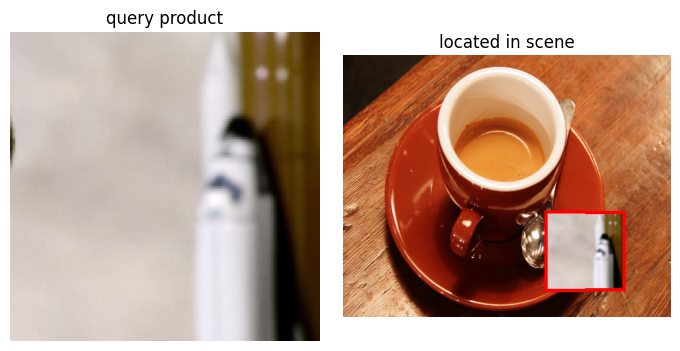

✓ PASS  Q4: locate (visual product search)


In [17]:
try:
    poly = locate(query, scene)
    c = poly.reshape(-1, 2).mean(0)
    tx, ty = OBJ_XY[0] + 60, OBJ_XY[1] + 60
    err = float(np.hypot(c[0] - tx, c[1] - ty))
    print(f'   outline centre ({c[0]:.0f},{c[1]:.0f}); true ({tx},{ty}); error {err:.1f}px')
    ok = err < 40
    vis = scene.copy(); cv2.polylines(vis, [np.int32(poly)], True, (255, 0, 0), 3)
    show_grid([query, vis], titles=['query product', 'located in scene'], cols=2)
    finish(save_as='lab_q4_search.png')
except Exception as e:
    ok = False; print('   error:', e)
check('Q4: locate (visual product search)', ok)

**Discussion questions.**
1. **Feature matching vs template matching vs a learned CNN embedding** — discuss the trade-offs for a shopping app with **millions** of products.
2. The shelf holds **three identical** products. Discuss how you'd find all of them, and when multi-instance detection gets hard.
3. A **reflective or low-texture** product won't match. Discuss what you'd change — features, capture/lighting, or a fallback method.